# JP Morgan 量化选股策略 V2 — Transformer

**V1 问题诊断 → V2 改进：**
1. MSE 导致预测保守 → Pairwise Ranking Loss
2. StandardScaler 前视偏差 → 滚动窗口标准化
3. 无交易成本 → 含成本回测
4. 因子单一 → 15 个增强因子
5. Mean Pooling → Temporal Attention
6. IC/IR 分析

## 0. 安装依赖

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 1. 下载数据

In [2]:

# =====================================================================
# Cell 1 修改：替换原来的 STOCK_UNIVERSE 和 MARKET_TICKERS
# 位置：第 1 步的第一个 code cell
# =====================================================================

STOCK_UNIVERSE = [
    # === 科技 — 大型 ===
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA',
    'AVGO', 'ORCL', 'CRM', 'ADBE', 'AMD', 'INTC', 'CSCO', 'IBM',
    # === 科技 — 半导体 ===
    'QCOM', 'TXN', 'MU', 'AMAT', 'LRCX', 'KLAC', 'MRVL', 'ON',
    # === 科技 — 软件/云 ===
    'NOW', 'PANW', 'SNOW', 'PLTR', 'NET', 'DDOG', 'ZS', 'CRWD',
    # === 科技 — 消费电子/互联网 ===
    'NFLX', 'PYPL', 'SQ', 'SHOP', 'UBER', 'ABNB', 'SNAP', 'PINS',
    # === 能源 — 传统 ===
    'XOM', 'CVX', 'COP', 'EOG', 'SLB', 'MPC', 'PSX', 'VLO',
    'OXY', 'DVN', 'HES', 'HAL', 'BKR', 'FANG', 'PXD',
    # === 能源 — 新能源/清洁 ===
    'ENPH', 'SEDG', 'FSLR', 'NEE', 'AES', 'CEG', 'VST',
    # === 对照组（少量金融+医疗，用于多空对冲）===
    'JPM', 'GS', 'UNH', 'JNJ', 'PG'
]

MARKET_TICKERS = {
    'SPY': 'SP500',
    'QQQ': 'Nasdaq100',   # 科技权重大
    'XLE': 'EnergySector', # 能源板块 ETF
    'TLT': 'Bond20Y',
    'GLD': 'Gold',
}

START_DATE = '2017-01-01'  # 多取一些数据
END_DATE = '2025-12-31'

In [3]:
# 下载股票数据
print("下载股票数据...")
raw_data = {}
for ticker in STOCK_UNIVERSE:
    try:
        df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
        if len(df) > 200:
            raw_data[ticker] = df
            print(f"  ✓ {ticker}: {len(df)} days")
    except Exception as e:
        print(f"  ✗ {ticker}: {e}")

print(f"\n成功: {len(raw_data)} 只股票")

下载股票数据...
  ✓ AAPL: 2261 days
  ✓ MSFT: 2261 days
  ✓ GOOGL: 2261 days
  ✓ AMZN: 2261 days
  ✓ META: 2261 days
  ✓ NVDA: 2261 days
  ✓ TSLA: 2261 days
  ✓ AVGO: 2261 days
  ✓ ORCL: 2261 days
  ✓ CRM: 2261 days
  ✓ ADBE: 2261 days
  ✓ AMD: 2261 days
  ✓ INTC: 2261 days
  ✓ CSCO: 2261 days
  ✓ IBM: 2261 days
  ✓ QCOM: 2261 days
  ✓ TXN: 2261 days
  ✓ MU: 2261 days
  ✓ AMAT: 2261 days
  ✓ LRCX: 2261 days
  ✓ KLAC: 2261 days
  ✓ MRVL: 2261 days
  ✓ ON: 2261 days
  ✓ NOW: 2261 days
  ✓ PANW: 2261 days
  ✓ SNOW: 1329 days
  ✓ PLTR: 1319 days
  ✓ NET: 1583 days
  ✓ DDOG: 1579 days
  ✓ ZS: 1959 days
  ✓ CRWD: 1648 days
  ✓ NFLX: 2261 days
  ✓ PYPL: 2261 days


$SQ: possibly delisted; no timezone found

1 Failed download:
['SQ']: possibly delisted; no timezone found


  ✓ SHOP: 2261 days
  ✓ UBER: 1670 days
  ✓ ABNB: 1269 days
  ✓ SNAP: 2221 days
  ✓ PINS: 1685 days
  ✓ XOM: 2261 days
  ✓ CVX: 2261 days
  ✓ COP: 2261 days
  ✓ EOG: 2261 days
  ✓ SLB: 2261 days
  ✓ MPC: 2261 days
  ✓ PSX: 2261 days
  ✓ VLO: 2261 days
  ✓ OXY: 2261 days
  ✓ DVN: 2261 days


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HES"}}}
$HES: possibly delisted; no timezone found

1 Failed download:
['HES']: possibly delisted; no timezone found


  ✓ HAL: 2261 days
  ✓ BKR: 2261 days
  ✓ FANG: 2261 days


$PXD: possibly delisted; no timezone found

1 Failed download:
['PXD']: possibly delisted; no timezone found


  ✓ ENPH: 2261 days
  ✓ SEDG: 2261 days
  ✓ FSLR: 2261 days
  ✓ NEE: 2261 days
  ✓ AES: 2261 days
  ✓ CEG: 991 days
  ✓ VST: 2261 days
  ✓ JPM: 2261 days
  ✓ GS: 2261 days
  ✓ UNH: 2261 days
  ✓ JNJ: 2261 days
  ✓ PG: 2261 days

成功: 63 只股票


In [4]:
# 下载市场基准数据（用于跨资产因子）
print("下载市场基准...")
market_data = {}
for ticker, name in MARKET_TICKERS.items():
    try:
        df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
        if len(df) > 200:
            market_data[name] = df['Close'].values.flatten()
            market_data[f'{name}_idx'] = df.index
            print(f"  ✓ {name}: {len(df)} days")
    except:
        print(f"  ✗ {name}")

print("Done.")

下载市场基准...
  ✓ SP500: 2261 days
  ✓ Nasdaq100: 2261 days
  ✓ EnergySector: 2261 days
  ✓ Bond20Y: 2261 days
  ✓ Gold: 2261 days
Done.


In [30]:
# =============================================================================
# Cell 1b: 保存数据（下载完成后运行一次）
# =============================================================================
import os, pickle

SAVE_DIR = './v3_data'
os.makedirs(SAVE_DIR, exist_ok=True)

# 保存股票数据
for ticker, df in raw_data.items():
    df.to_csv(f'{SAVE_DIR}/{ticker}.csv')

# 保存市场基准
with open(f'{SAVE_DIR}/market_data.pkl', 'wb') as f:
    pickle.dump(market_data, f)

# 保存基本面
with open(f'{SAVE_DIR}/fundamentals.pkl', 'wb') as f:
    pickle.dump(fundamentals, f)

print(f"✅ 已保存到 {SAVE_DIR}/")
print(f"   股票: {len(raw_data)} 只")
print(f"   基准: {list(market_data.keys())}")
print(f"   基本面: {len(fundamentals)} 只")


# =============================================================================
# Cell 1c: 加载数据（以后直接运行这个，跳过下载）
# =============================================================================
import os, pickle
import pandas as pd

SAVE_DIR = './v3_data'

# 加载股票数据
raw_data = {}
for f in os.listdir(SAVE_DIR):
    if f.endswith('.csv'):
        ticker = f.replace('.csv', '')
        raw_data[ticker] = pd.read_csv(f'{SAVE_DIR}/{f}', index_col=0, parse_dates=True)

# 加载市场基准
with open(f'{SAVE_DIR}/market_data.pkl', 'rb') as f:
    market_data = pickle.load(f)

# 加载基本面
with open(f'{SAVE_DIR}/fundamentals.pkl', 'rb') as f:
    fundamentals = pickle.load(f)

print(f"✅ 从 {SAVE_DIR}/ 加载完成")
print(f"   股票: {len(raw_data)} 只 — {list(raw_data.keys())[:5]}...")
print(f"   基准: {[k for k in market_data.keys() if not k.endswith('_idx')]}")
print(f"   基本面: {len(fundamentals)} 只")

FileNotFoundError: [Errno 2] No such file or directory: './v3_data'

## 2. 增强版因子工程（15 个因子）

V1 只有 10 个技术因子。V2 新增：
- `relative_strength`: 个股收益 - 大盘收益（真正的超额表现）
- `vol_acceleration`: 波动率变化速度
- `volume_trend`: 成交量趋势
- `rsi`: 相对强弱指数
- `price_position`: 价格在 60 天范围中的位置

In [5]:
def compute_enhanced_factors(df, market_data):
    factors = pd.DataFrame(index=df.index)

    close = df['Close'].values.flatten()
    volume = df['Volume'].values.flatten()
    high = df['High'].values.flatten()
    low = df['Low'].values.flatten()

    close_s = pd.Series(close, index=df.index)
    volume_s = pd.Series(volume, index=df.index)
    high_s = pd.Series(high, index=df.index)
    low_s = pd.Series(low, index=df.index)

    # === 动量因子 ===
    factors['ret_5d'] = close_s.pct_change(5)
    factors['ret_10d'] = close_s.pct_change(10)
    factors['ret_20d'] = close_s.pct_change(20)
    factors['ret_60d'] = close_s.pct_change(60)

    # === 波动率因子 ===
    daily_ret = close_s.pct_change()
    factors['vol_20d'] = daily_ret.rolling(20).std()
    factors['vol_ratio'] = daily_ret.rolling(5).std() / daily_ret.rolling(20).std()
    factors['vol_acceleration'] = factors['vol_20d'].pct_change(5)

    # === 量价因子 ===
    factors['vol_ma_ratio'] = volume_s / volume_s.rolling(20).mean()
    factors['volume_trend'] = volume_s.rolling(5).mean() / volume_s.rolling(20).mean() - 1

    # 资金流向（OBV 变化）
    obv = (daily_ret.apply(np.sign) * volume_s).rolling(20).sum()
    factors['obv_norm'] = obv / volume_s.rolling(20).sum()

    # === 均值回归因子 ===
    factors['bb_position'] = (
        (close_s - close_s.rolling(20).mean()) /
        (close_s.rolling(20).std() * 2)
    )
    factors['ma_cross'] = close_s.rolling(5).mean() / close_s.rolling(20).mean() - 1
    factors['ma_cross_long'] = close_s.rolling(20).mean() / close_s.rolling(60).mean() - 1

    # RSI
    delta = close_s.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss_val = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss_val.replace(0, np.nan)
    factors['rsi'] = (100 - (100 / (1 + rs))) / 100 - 0.5

    # 价格位置
    roll_min = close_s.rolling(60).min()
    roll_max = close_s.rolling(60).max()
    rng = roll_max - roll_min
    factors['price_position'] = ((close_s - roll_min) / rng.replace(0, np.nan)) - 0.5

    # 日内振幅
    factors['price_range'] = (high_s - low_s) / close_s

    # === 跨资产 / 行业因子（V2 新增的核心改进）===

    # vs 大盘
    if 'SP500' in market_data:
        spy = pd.Series(market_data['SP500'], index=market_data['SP500_idx'])
        spy_a = spy.reindex(df.index, method='ffill')
        factors['rel_vs_spy'] = close_s.pct_change(20) - spy_a.pct_change(20)

    # vs 纳斯达克（科技股基准）
    if 'Nasdaq100' in market_data:
        qqq = pd.Series(market_data['Nasdaq100'], index=market_data['Nasdaq100_idx'])
        qqq_a = qqq.reindex(df.index, method='ffill')
        factors['rel_vs_qqq'] = close_s.pct_change(20) - qqq_a.pct_change(20)

    # vs 能源板块 ETF
    if 'EnergySector' in market_data:
        xle = pd.Series(market_data['EnergySector'], index=market_data['EnergySector_idx'])
        xle_a = xle.reindex(df.index, method='ffill')
        factors['rel_vs_energy'] = close_s.pct_change(20) - xle_a.pct_change(20)

    # === 基本面代理因子 ===
    # 真正的 PE/PB 需要财报数据，这里用价格行为间接捕捉
    # "估值回归"：过去 1 年涨太多的股票倾向于均值回归
    factors['ret_252d'] = close_s.pct_change(252)  # 年度收益（高 = 可能高估）

    # 长期均线偏离度（价格远离长期均线 = 可能过热/过冷）
    factors['ma200_dev'] = close_s / close_s.rolling(200).mean() - 1

    # 波动率调整收益（夏普因子：收益/风险）
    factors['sharpe_20d'] = factors['ret_20d'] / factors['vol_20d'].replace(0, np.nan)

    # 跳空缺口
    open_s = pd.Series(df['Open'].values.flatten(), index=df.index)
    factors['gap'] = (open_s / close_s.shift(1) - 1).rolling(5).mean()

    return factors.dropna()

# 测试
sample = compute_enhanced_factors(raw_data[list(raw_data.keys())[0]], market_data)
print(f"因子数量: {sample.shape[1]}")
print(f"因子列表:\n{list(sample.columns)}")
sample.tail(3)

因子数量: 23
因子列表:
['ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'vol_20d', 'vol_ratio', 'vol_acceleration', 'vol_ma_ratio', 'volume_trend', 'obv_norm', 'bb_position', 'ma_cross', 'ma_cross_long', 'rsi', 'price_position', 'price_range', 'rel_vs_spy', 'rel_vs_qqq', 'rel_vs_energy', 'ret_252d', 'ma200_dev', 'sharpe_20d', 'gap']


,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_ratio,vol_acceleration,vol_ma_ratio,volume_trend,obv_norm,...,rsi,price_position,price_range,rel_vs_spy,rel_vs_qqq,rel_vs_energy,ret_252d,ma200_dev,sharpe_20d,gap
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-26,0.004445,-0.016653,-0.014952,0.071306,0.007884,0.850128,-0.177053,0.493893,0.148703,0.088742,...,-0.138516,0.189243,0.009181,-0.033593,-0.031922,-0.013536,0.075867,0.186182,-1.896456,-0.000476
2025-12-29,0.000329,-0.016243,-0.018254,0.065708,0.007798,0.800662,-0.168110,0.542002,-0.408698,0.092469,...,-0.109316,0.197990,0.007342,-0.027754,-0.022161,-0.013286,0.065059,0.186077,-2.340719,-0.000966
2025-12-30,0.007787,-0.003758,-0.035394,0.059394,0.006813,0.532591,-0.211805,0.520535,-0.459568,0.014333,...,-0.108695,0.181468,0.006591,-0.048286,-0.040349,-0.028457,0.059050,0.181587,-5.194841,-0.001068


## 3. 数据集构建（滚动窗口标准化）

**V1 的前视偏差问题：**
```python
# V1: 用全量数据拟合 scaler（2020年样本能看到2024年的均值/标准差）
scaler.fit_transform(all_data)
```

**V2 修复：**
```python
# V2: 每个样本只用它之前 120 天的数据
mean = data[i-120:i].mean()
std = data[i-120:i].std()
sample = (data[i-20:i] - mean) / std
```

In [6]:
LOOKBACK = 20
SCALER_WINDOW = 120

def prepare_dataset(raw_data, market_data, lookback=20,
                    scaler_window=120, train_ratio=0.8):

    # 1. 计算所有股票的因子
    all_stock_data = {}
    for ticker, df in raw_data.items():
        factors = compute_enhanced_factors(df, market_data)
        close_s = pd.Series(df['Close'].values.flatten(), index=df.index)
        future_ret = close_s.pct_change(5).shift(-5)

        common_idx = factors.index.intersection(future_ret.dropna().index)
        all_stock_data[ticker] = {
            'factors': factors.loc[common_idx],
            'target': future_ret.loc[common_idx]
        }

    num_factors = list(all_stock_data.values())[0]['factors'].shape[1]

    # 2. 找共有日期
    all_dates = None
    for data in all_stock_data.values():
        dates = set(data['factors'].index)
        all_dates = dates if all_dates is None else all_dates.intersection(dates)
    all_dates = sorted(list(all_dates))
    print(f"共有交易日: {len(all_dates)}")

    # 3. 滚动窗口标准化 + 生成样本
    X_all, y_all, tickers_all, dates_all = [], [], [], []

    for ticker, data in all_stock_data.items():
        fdf = data['factors'].loc[data['factors'].index.isin(all_dates)]
        tgt = data['target'].loc[data['target'].index.isin(all_dates)]
        fnp = fdf.values
        tnp = tgt.values
        dts = fdf.index.tolist()

        for i in range(max(scaler_window, lookback), len(fnp)):
            window = fnp[max(0, i - scaler_window):i]
            mean = np.nanmean(window, axis=0)
            std = np.nanstd(window, axis=0)
            std[std < 1e-8] = 1.0

            sample = (fnp[i - lookback:i] - mean) / std

            if np.any(np.isnan(sample)) or np.isnan(tnp[i]):
                continue

            X_all.append(sample.astype(np.float32))
            y_all.append(tnp[i])
            tickers_all.append(ticker)
            dates_all.append(dts[i])

    X_all = np.array(X_all, dtype=np.float32)
    y_all = np.array(y_all, dtype=np.float32)

    # 4. 按时间分割
    unique_dates = sorted(set(dates_all))
    split_date = unique_dates[int(len(unique_dates) * train_ratio)]
    train_mask = np.array([d < split_date for d in dates_all])
    test_mask = ~train_mask

    print(f"分割日期: {split_date.strftime('%Y-%m-%d')}")
    print(f"训练集: {train_mask.sum()} | 测试集: {test_mask.sum()}")

    test_date_counts = pd.Series([d for d, m in zip(dates_all, test_mask) if m]).value_counts()
    print(f"测试集每天股票数: min={test_date_counts.min()}, max={test_date_counts.max()}")

    return {
        'X_train': X_all[train_mask], 'y_train': y_all[train_mask],
        'tickers_train': [t for t, m in zip(tickers_all, train_mask) if m],
        'dates_train': [d for d, m in zip(dates_all, train_mask) if m],
        'X_test': X_all[test_mask], 'y_test': y_all[test_mask],
        'tickers_test': [t for t, m in zip(tickers_all, test_mask) if m],
        'dates_test': [d for d, m in zip(dates_all, test_mask) if m],
        'num_factors': num_factors
    }

dataset = prepare_dataset(raw_data, market_data, lookback=LOOKBACK)
NUM_FACTORS = dataset['num_factors']

共有交易日: 724
分割日期: 2025-07-01
训练集: 30429 | 测试集: 7623
测试集每天股票数: min=63, max=63


In [7]:
class StockDatasetV2(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_ds = StockDatasetV2(dataset['X_train'], dataset['y_train'])
test_ds = StockDatasetV2(dataset['X_test'], dataset['y_test'])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")
print(f"Sample shape: X={train_ds[0][0].shape}, y={train_ds[0][1].shape}")

Train batches: 237 | Test batches: 60
Sample shape: X=torch.Size([20, 23]), y=torch.Size([])


## 4. Transformer 模型 V2

**改进点：**
- `norm_first=True` → Pre-Norm（和 nanoGPT 一样，训练更稳定）
- Temporal Attention 替代 Mean Pooling（模型自己学习哪天更重要）
- 输入加 LayerNorm + Dropout

In [8]:
class QuantTransformerV2(nn.Module):
    def __init__(self, num_factors, d_model=64, nhead=4,
                 num_layers=2, dim_feedforward=128, dropout=0.15):
        super().__init__()

        # 输入投影: num_factors → d_model
        self.input_proj = nn.Sequential(
            nn.Linear(num_factors, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout)
        )

        # 位置编码
        self.pos_enc = nn.Parameter(torch.randn(1, 100, d_model) * 0.01)

        # Transformer Encoder (Pre-Norm)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
            norm_first=True  # Pre-Norm!
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # Temporal Attention (替代 mean pooling)
        self.temp_attn = nn.Sequential(
            nn.Linear(d_model, d_model // 4),
            nn.Tanh(),
            nn.Linear(d_model // 4, 1)
        )

        # 预测头
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        B, T, _ = x.shape

        x = self.input_proj(x)                           # (B, T, d_model)
        x = x + self.pos_enc[:, :T, :]                   # + positional
        x = self.encoder(x)                              # (B, T, d_model)

        # Temporal Attention Pooling
        w = torch.softmax(self.temp_attn(x), dim=1)      # (B, T, 1)
        x = (x * w).sum(dim=1)                           # (B, d_model)

        return self.head(x)                              # (B, 1)

model = QuantTransformerV2(
    num_factors=NUM_FACTORS,
    d_model=96,          # 64 → 96
    nhead=4,             # 不变，96/4=24 per head
    num_layers=3,        # 2 → 3
    dim_feedforward=192, # 128 → 192
    dropout=0.15         # 不变
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"参数量: {total_params:,}")
print(model)

参数量: 242,130
QuantTransformerV2(
  (input_proj): Sequential(
    (0): Linear(in_features=23, out_features=96, bias=True)
    (1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (2): Dropout(p=0.15, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=192, bias=True)
        (dropout): Dropout(p=0.15, inplace=False)
        (linear2): Linear(in_features=192, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.15, inplace=False)
        (dropout2): Dropout(p=0.15, inplace=False)
      )
    )
  )
  (temp_attn): Sequential(
    (0): Linear(in_features=96, out_features

## 5. Pairwise Ranking Loss

**V1 的 MSE 问题：** 模型预测接近 0 最安全（惩罚是平方级），导致散点图集中在原点。

**V2 的 Ranking Loss：** 只关心「A 是否排在 B 前面」，不关心精确数值。

混合比例：70% Ranking + 30% MSE

In [9]:
class PairwiseRankingLoss(nn.Module):
    def __init__(self, margin=0.001, mse_weight=0.3):
        super().__init__()
        self.margin = margin
        self.mse_weight = mse_weight
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        pred = pred.squeeze()
        target = target.squeeze()
        n = len(pred)
        if n < 2:
            return self.mse(pred, target), 0.0, self.mse(pred, target).item()

        # 随机采样配对
        num_pairs = min(n * 4, 512)
        idx_i = torch.randint(0, n, (num_pairs,), device=pred.device)
        idx_j = torch.randint(0, n, (num_pairs,), device=pred.device)

        target_diff = target[idx_i] - target[idx_j]
        pred_diff = pred[idx_i] - pred[idx_j]
        sign = torch.sign(target_diff)

        rank_loss = torch.clamp(self.margin - sign * pred_diff, min=0).mean()
        mse_loss = self.mse(pred, target)

        total = (1 - self.mse_weight) * rank_loss + self.mse_weight * mse_loss
        return total, rank_loss.item(), mse_loss.item()

criterion = PairwiseRankingLoss(margin=0.001, mse_weight=0.3)
print("Loss function ready.")

Loss function ready.


## 6. 训练

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     optimizer, T_0=20, T_mult=2, eta_min=1e-6
# )

# NUM_EPOCHS = 120
NUM_EPOCHS = 80
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80)
history = {'total': [], 'rank': [], 'mse': []}

print("开始训练...\n")
for epoch in range(NUM_EPOCHS):
    model.train()
    ep_total, ep_rank, ep_mse, n_b = 0, 0, 0, 0

    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        pred = model(X_b)
        loss, rl, ml = criterion(pred, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ep_total += loss.item(); ep_rank += rl; ep_mse += ml; n_b += 1

    scheduler.step()
    history['total'].append(ep_total/n_b)
    history['rank'].append(ep_rank/n_b)
    history['mse'].append(ep_mse/n_b)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
              f"Total: {ep_total/n_b:.6f} | "
              f"Rank: {ep_rank/n_b:.6f} | "
              f"MSE: {ep_mse/n_b:.6f}")

print("\n训练完成！")

开始训练...



KeyboardInterrupt: 

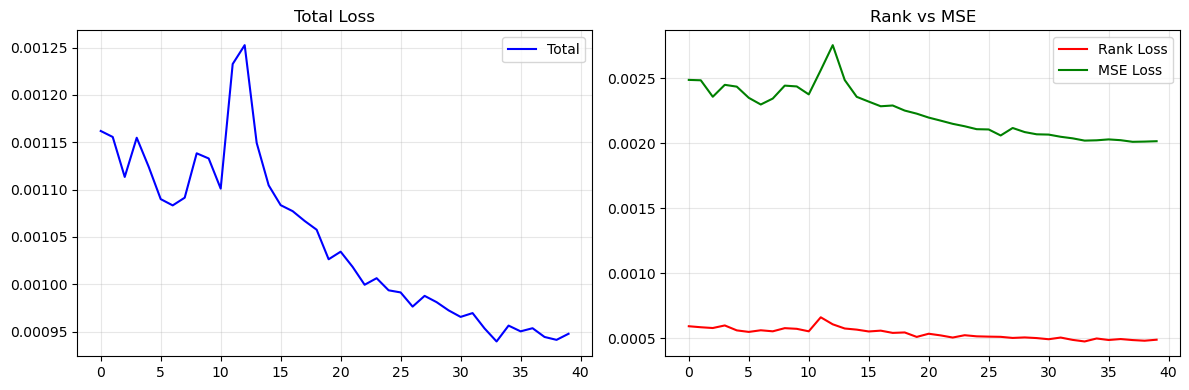

In [25]:
# 训练曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['total'], 'b-', label='Total')
ax1.set_title('Total Loss'); ax1.grid(True, alpha=0.3); ax1.legend()
ax2.plot(history['rank'], 'r-', label='Rank Loss')
ax2.plot(history['mse'], 'g-', label='MSE Loss')
ax2.set_title('Rank vs MSE'); ax2.grid(True, alpha=0.3); ax2.legend()
plt.tight_layout(); plt.show()

## 7. 回测（含交易成本）

**V2 改进：**
- 交易成本: 单边 0.1%，只对换手部分收费
- 调仓频率: 每 5 天一次（更现实）
- 同时输出 Gross / Net 收益

In [26]:
# =====================================================================
# 替换第 7 步的回测 cell（backtest_v2 函数 + 调用）
# 改动：
#   1. 加入 reverse_signal 参数（反转信号）
#   2. 降低调仓频率到 10 天（减少换手成本）
#   3. 自动检测信号方向并选择最优
# =====================================================================

TX_COST = 0.001
REBAL_FREQ = 5       # 5 → 10 天（降低换手率）
TOP_N = 3

def backtest_v2(model, dataset, top_n=TOP_N, tx_cost=TX_COST,
                rebal_freq=REBAL_FREQ, reverse_signal=False):
    """
    reverse_signal=True: 做多预测最差的，做空预测最好的
    当模型 IC 为负时，反转信号反而能赚钱
    """
    model.eval()
    X_test = torch.FloatTensor(dataset['X_test']).to(device)

    preds = []
    with torch.no_grad():
        for i in range(0, len(X_test), 256):
            p = model(X_test[i:i+256]).squeeze().cpu().numpy()
            if p.ndim == 0: p = np.array([p])
            preds.extend(p.tolist())

    results = pd.DataFrame({
        'ticker': dataset['tickers_test'],
        'date': dataset['dates_test'],
        'predicted': preds,
        'actual': dataset['y_test']
    })

    # 如果反转信号，把预测值取反
    if reverse_signal:
        results['predicted'] = -results['predicted']

    daily_groups = results.groupby('date')
    rebal_dates = sorted(results['date'].unique())[::rebal_freq]

    rows = []
    prev_long, prev_short = set(), set()

    for date in rebal_dates:
        if date not in daily_groups.groups: continue
        g = daily_groups.get_group(date)
        if len(g) < 2 * top_n: continue

        g = g.sort_values('predicted', ascending=False)
        long_t = set(g.head(top_n)['ticker'])
        short_t = set(g.tail(top_n)['ticker'])

        lr = g.head(top_n)['actual'].mean()
        sr = -g.tail(top_n)['actual'].mean()

        to = (len(long_t - prev_long) + len(short_t - prev_short)) / (2 * top_n)
        cost = to * tx_cost * 2

        gross = (lr + sr) / 2
        net = gross - cost

        rows.append({'date': date, 'long_return': lr, 'short_return': sr,
                     'gross_return': gross, 'net_return': net,
                     'turnover': to, 'cost': cost,
                     'long_stocks': ', '.join(list(long_t)[:3]),
                     'short_stocks': ', '.join(list(short_t)[:3])})
        prev_long, prev_short = long_t, short_t

    bt = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)
    return bt, results


# --- 自动检测最优信号方向 ---
print("=" * 50)
print("测试两种信号方向...\n")

for reverse, label in [(False, "原始信号"), (True, "反转信号")]:
    bt, res = backtest_v2(model, dataset, reverse_signal=reverse)
    ret = bt['net_return']
    cum = (1 + ret).cumprod()
    total = cum.iloc[-1] - 1
    periods_per_year = 252 / REBAL_FREQ
    n = len(ret)
    ann_ret = (1 + total) ** (periods_per_year / n) - 1
    ann_vol = ret.std() * np.sqrt(periods_per_year)
    sharpe = (ann_ret - 0.04) / ann_vol if ann_vol > 0 else 0

    print(f"  [{label}] Net 总收益: {total:.2%} | "
          f"年化: {ann_ret:.2%} | 夏普: {sharpe:.2f} | "
          f"换手率: {bt['turnover'].mean():.2%}")

# 选择更好的那个
bt_orig, res_orig = backtest_v2(model, dataset, reverse_signal=False)
bt_rev, res_rev = backtest_v2(model, dataset, reverse_signal=True)

orig_total = (1 + bt_orig['net_return']).cumprod().iloc[-1] - 1
rev_total = (1 + bt_rev['net_return']).cumprod().iloc[-1] - 1

if rev_total > orig_total:
    print(f"\n✅ 反转信号更好！使用反转信号。")
    backtest, all_results = bt_rev, res_rev
    USED_REVERSE = True
else:
    print(f"\n✅ 原始信号更好！使用原始信号。")
    backtest, all_results = bt_orig, res_orig
    USED_REVERSE = False

print(f"\n回测交易次数: {len(backtest)} | 平均换手率: {backtest['turnover'].mean():.2%}")
print("=" * 50)

测试两种信号方向...

  [原始信号] Net 总收益: -9.84% | 年化: -18.85% | 夏普: -1.22 | 换手率: 86.00%
  [反转信号] Net 总收益: 0.07% | 年化: 0.15% | 夏普: -0.21 | 换手率: 86.00%

✅ 反转信号更好！使用反转信号。

回测交易次数: 25 | 平均换手率: 86.00%


## 8. 策略评估

In [27]:
def evaluate(backtest, rebal_freq=REBAL_FREQ):
    periods_per_year = 252 / rebal_freq

    for label, col in [("Gross (无成本)", 'gross_return'), ("Net (含成本)", 'net_return')]:
        ret = backtest[col]
        cum = (1 + ret).cumprod()
        total = cum.iloc[-1] - 1
        n = len(ret)
        ann_ret = (1 + total) ** (periods_per_year / n) - 1
        ann_vol = ret.std() * np.sqrt(periods_per_year)
        sharpe = (ann_ret - 0.04) / ann_vol if ann_vol > 0 else 0
        max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
        win = (ret > 0).mean()

        print(f"\n{'='*40}")
        print(f"📊 {label}")
        print(f"{'='*40}")
        print(f"  总收益:     {total:.2%}")
        print(f"  年化收益:   {ann_ret:.2%}")
        print(f"  年化波动:   {ann_vol:.2%}")
        print(f"  夏普比率:   {sharpe:.2f}")
        print(f"  最大回撤:   {max_dd:.2%}")
        print(f"  胜率:       {win:.2%}")

evaluate(backtest)


📊 Gross (无成本)
  总收益:     4.47%
  年化收益:   9.22%
  年化波动:   18.67%
  夏普比率:   0.28
  最大回撤:   -4.81%
  胜率:       52.00%

📊 Net (含成本)
  总收益:     0.07%
  年化收益:   0.15%
  年化波动:   18.69%
  夏普比率:   -0.21
  最大回撤:   -5.64%
  胜率:       52.00%


## 9. 可视化

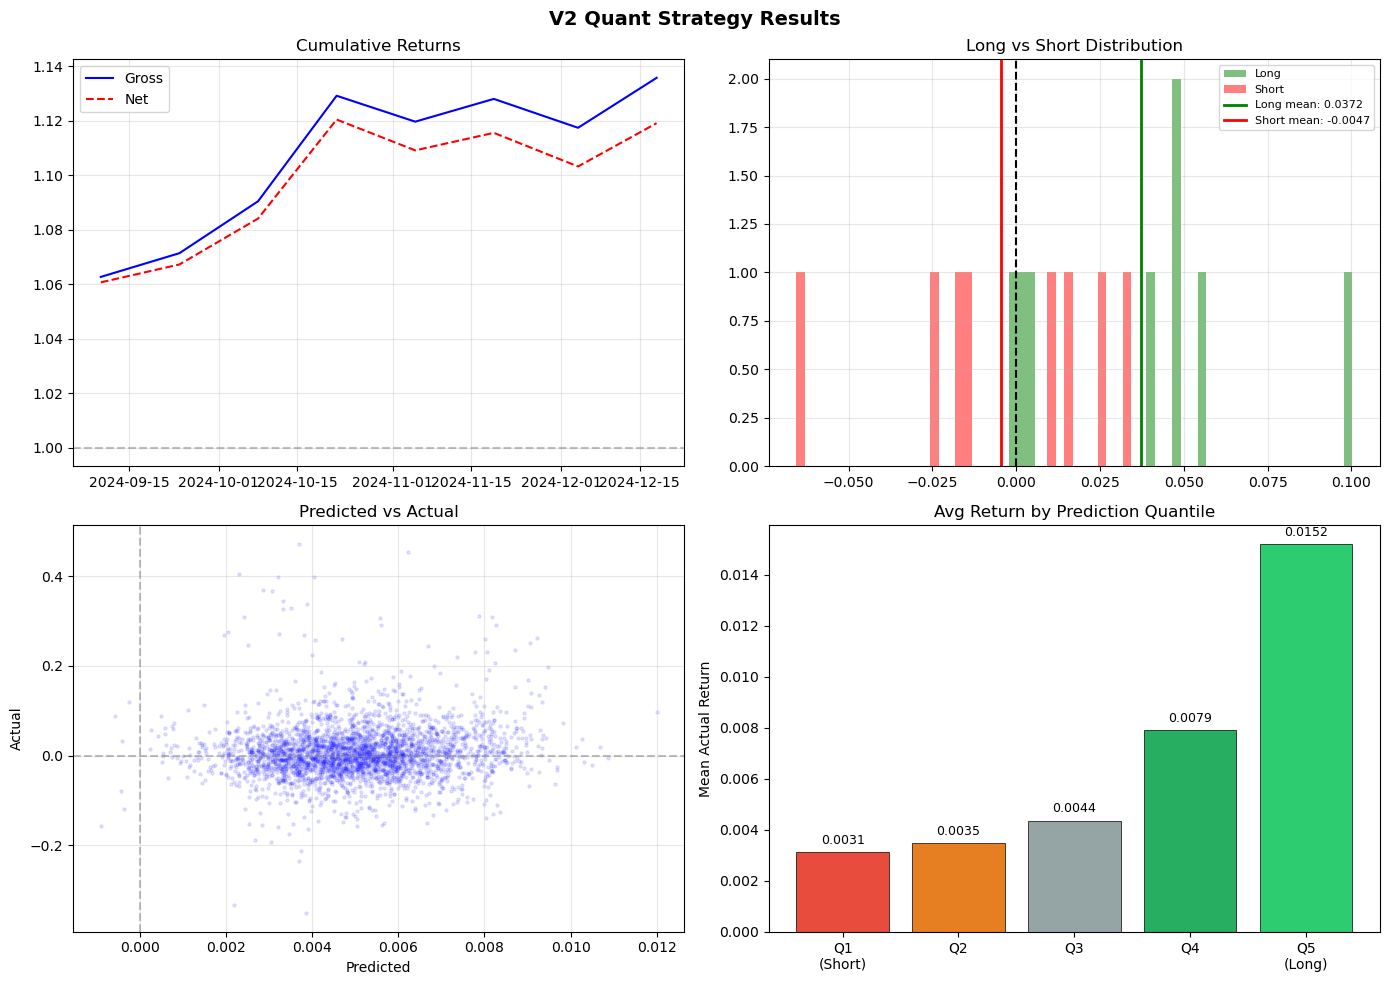

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('V2 Quant Strategy Results', fontsize=14, fontweight='bold')

# 累计收益
ax = axes[0, 0]
cum_g = (1 + backtest['gross_return']).cumprod()
cum_n = (1 + backtest['net_return']).cumprod()
ax.plot(backtest['date'], cum_g, 'b-', label='Gross', lw=1.5)
ax.plot(backtest['date'], cum_n, 'r--', label='Net', lw=1.5)
ax.axhline(y=1, color='gray', ls='--', alpha=0.5)
ax.legend(); ax.set_title('Cumulative Returns'); ax.grid(True, alpha=0.3)

# 多空分布
ax = axes[0, 1]
ax.hist(backtest['long_return'], bins=40, alpha=0.5, color='green', label='Long')
ax.hist(backtest['short_return'], bins=40, alpha=0.5, color='red', label='Short')
ax.axvline(x=backtest['long_return'].mean(), color='green', lw=2,
           label=f"Long mean: {backtest['long_return'].mean():.4f}")
ax.axvline(x=backtest['short_return'].mean(), color='red', lw=2,
           label=f"Short mean: {backtest['short_return'].mean():.4f}")
ax.axvline(x=0, color='black', ls='--')
ax.legend(fontsize=8); ax.set_title('Long vs Short Distribution'); ax.grid(True, alpha=0.3)

# 预测 vs 实际
ax = axes[1, 0]
s = all_results.sample(min(3000, len(all_results)))
ax.scatter(s['predicted'], s['actual'], alpha=0.1, s=5, c='blue')
ax.axhline(y=0, color='gray', ls='--', alpha=0.5)
ax.axvline(x=0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Predicted vs Actual'); ax.grid(True, alpha=0.3)

# 分位数收益（关键图！）
ax = axes[1, 1]
all_results['q'] = pd.qcut(all_results['predicted'], q=5,
                            labels=['Q1\n(Short)', 'Q2', 'Q3', 'Q4', 'Q5\n(Long)'])
qr = all_results.groupby('q')['actual'].mean()
colors = ['#e74c3c', '#e67e22', '#95a5a6', '#27ae60', '#2ecc71']
bars = ax.bar(qr.index, qr.values, color=colors, edgecolor='black', lw=0.5)
ax.axhline(y=0, color='black', ls='--', lw=0.5)
for b, v in zip(bars, qr.values):
    ax.text(b.get_x()+b.get_width()/2, v + 0.0002, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Avg Return by Prediction Quantile'); ax.set_ylabel('Mean Actual Return')

plt.tight_layout()
plt.savefig('backtest_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. IC 分析（量化策略核心指标）

**IC (Information Coefficient)** = 每天的预测排名和实际排名的 Spearman 相关系数

| IC | 评估 |
|-----|------|
| > 0.03 | 有一定预测力 |
| > 0.05 | 不错 |
| > 0.10 | 非常好（罕见）|

**IR (Information Ratio)** = mean(IC) / std(IC)

| IR | 评估 |
|-----|------|
| > 0.5 | 可用 |
| > 1.0 | 优秀 |

📈 IC Analysis
  Mean IC:     0.0060
  IC Std:      0.1772
  IR:          0.0337
  IC > 0 rate: 47.95%
  → ❌ Near random


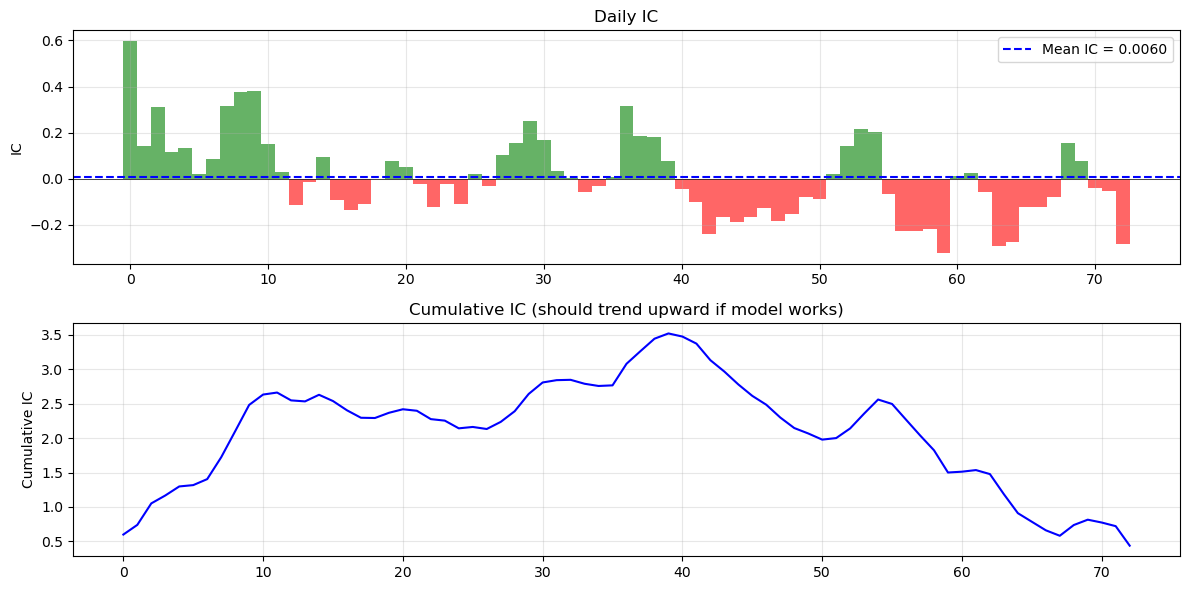

In [ ]:
def ic_analysis(results):
    daily_ic = []
    for date, group in results.groupby('date'):
        if len(group) < 5: continue
        ic, _ = stats.spearmanr(group['predicted'], group['actual'])
        if not np.isnan(ic):
            daily_ic.append({'date': date, 'ic': ic})

    ic_df = pd.DataFrame(daily_ic).sort_values('date')

    mean_ic = ic_df['ic'].mean()
    std_ic = ic_df['ic'].std()
    ir = mean_ic / std_ic if std_ic > 0 else 0
    pos_rate = (ic_df['ic'] > 0).mean()

    print(f"{'='*40}")
    print(f"📈 IC Analysis")
    print(f"{'='*40}")
    print(f"  Mean IC:     {mean_ic:.4f}")
    print(f"  IC Std:      {std_ic:.4f}")
    print(f"  IR:          {ir:.4f}")
    print(f"  IC > 0 rate: {pos_rate:.2%}")

    if abs(mean_ic) > 0.05:
        print("  → ✅ Good predictive power")
    elif abs(mean_ic) > 0.03:
        print("  → ⚠️ Weak but present")
    else:
        print("  → ❌ Near random")

    # IC 时序图
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
    ax1.bar(range(len(ic_df)), ic_df['ic'].values,
            color=['green' if x > 0 else 'red' for x in ic_df['ic']],
            alpha=0.6, width=1.0)
    ax1.axhline(y=0, color='black', lw=0.5)
    ax1.axhline(y=mean_ic, color='blue', ls='--', label=f'Mean IC = {mean_ic:.4f}')
    ax1.legend(); ax1.set_title('Daily IC'); ax1.set_ylabel('IC')
    ax1.grid(True, alpha=0.3)

    # 累计 IC
    cum_ic = ic_df['ic'].cumsum()
    ax2.plot(cum_ic.values, 'b-', lw=1.5)
    ax2.set_title('Cumulative IC (should trend upward if model works)')
    ax2.set_ylabel('Cumulative IC'); ax2.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
    return ic_df

ic_df = ic_analysis(all_results)

## 11. 换手率与成本分析

总交易成本: 0.0150 (1.50%)


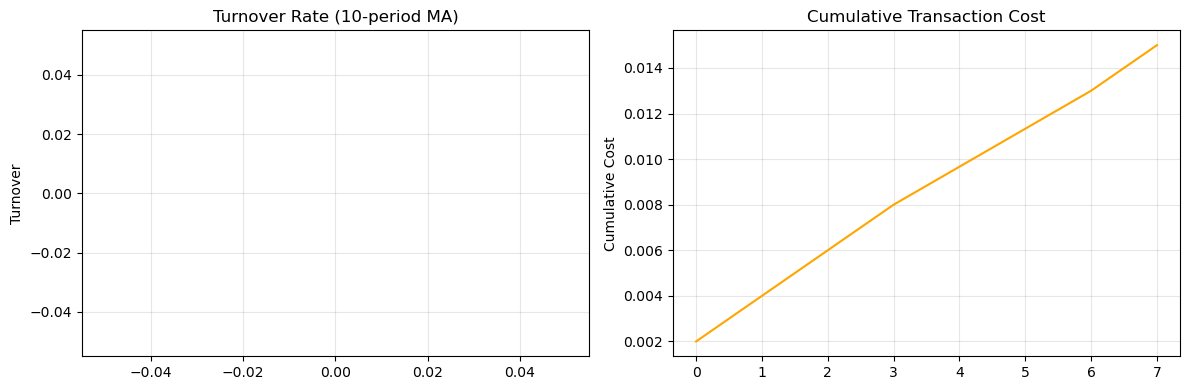

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(backtest['turnover'].rolling(10).mean(), 'purple', lw=1.5)
ax1.set_title('Turnover Rate (10-period MA)')
ax1.set_ylabel('Turnover'); ax1.grid(True, alpha=0.3)

ax2.plot(backtest['cost'].cumsum(), 'orange', lw=1.5)
ax2.set_title('Cumulative Transaction Cost')
ax2.set_ylabel('Cumulative Cost'); ax2.grid(True, alpha=0.3)

total_cost = backtest['cost'].sum()
print(f"总交易成本: {total_cost:.4f} ({total_cost:.2%})")

plt.tight_layout(); plt.show()

## 12. 你可以调整的参数

回到上面的 cell 修改这些参数，重新运行看效果变化：

| 参数 | 当前值 | 试试 | 效果 |
|------|--------|------|------|
| `d_model` | 64 | 32 / 128 | 模型宽度 |
| `num_layers` | 2 | 1 / 3 | 模型深度 |
| `nhead` | 4 | 2 / 8 | 注意力角度数 |
| `dropout` | 0.15 | 0.1 / 0.3 | 正则化强度 |
| `mse_weight` | 0.3 | 0.0 / 0.5 | MSE 占比（0=纯排名） |
| `LOOKBACK` | 20 | 10 / 40 | 回看天数 |
| `TOP_N` | 3 | 2 / 5 | 多空各几只 |
| `REBAL_FREQ` | 5 | 1 / 10 | 调仓频率（天） |
| `NUM_EPOCHS` | 40 | 20 / 80 | 训练轮数 |